count    7000.000000
mean        1.512487
std         1.395452
min         0.000000
25%         0.500000
50%         1.246322
75%         2.000000
max         9.250000
Name: YearsAtCompany, dtype: float64
X shape: (7000, 46) y shape: (7000,)
RSF C-index: 0.9611695334365914


/usr/local/lib/python3.11/dist-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.710. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


DeepSurv (CoxPH) C-index: 0.9369297513894748


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:21:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meta AUC: 0.9733 | Accuracy: 0.9157 | Precision: 0.8565 | Recall: 0.9504


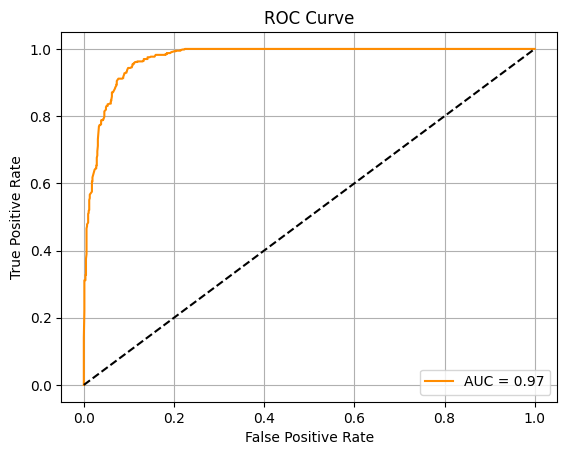

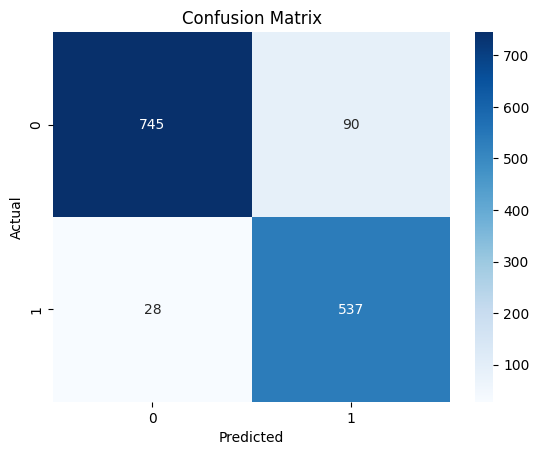

/tmp/ipython-input-2596902770.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected_time = np.trapz(surv_func.y, surv_func.x)


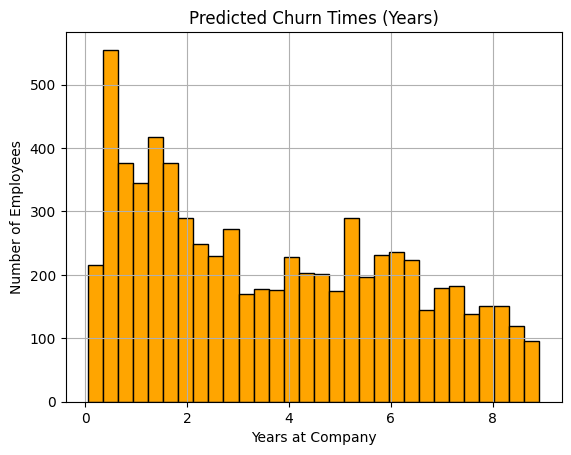

Employee 1 likely to churn in approx. 4.41 years.
Employee 2 likely to churn in approx. 1.79 years.
Employee 3 likely to churn in approx. 5.41 years.
Employee 4 likely to churn in approx. 0.09 years.
Employee 5 likely to churn in approx. 5.72 years.
Employee 6 likely to churn in approx. 2.76 years.
Employee 7 likely to churn in approx. 1.04 years.
Employee 8 likely to churn in approx. 5.05 years.
Employee 9 likely to churn in approx. 0.42 years.
Employee 10 likely to churn in approx. 5.07 years.
Employee 11 likely to churn in approx. 2.60 years.
Employee 12 likely to churn in approx. 0.58 years.
Employee 13 likely to churn in approx. 0.31 years.
Employee 14 likely to churn in approx. 1.91 years.
Employee 15 likely to churn in approx. 6.81 years.
Employee 16 likely to churn in approx. 1.28 years.
Employee 17 likely to churn in approx. 8.37 years.
Employee 18 likely to churn in approx. 7.05 years.
Employee 19 likely to churn in approx. 1.86 years.
Employee 20 likely to churn in approx. 5

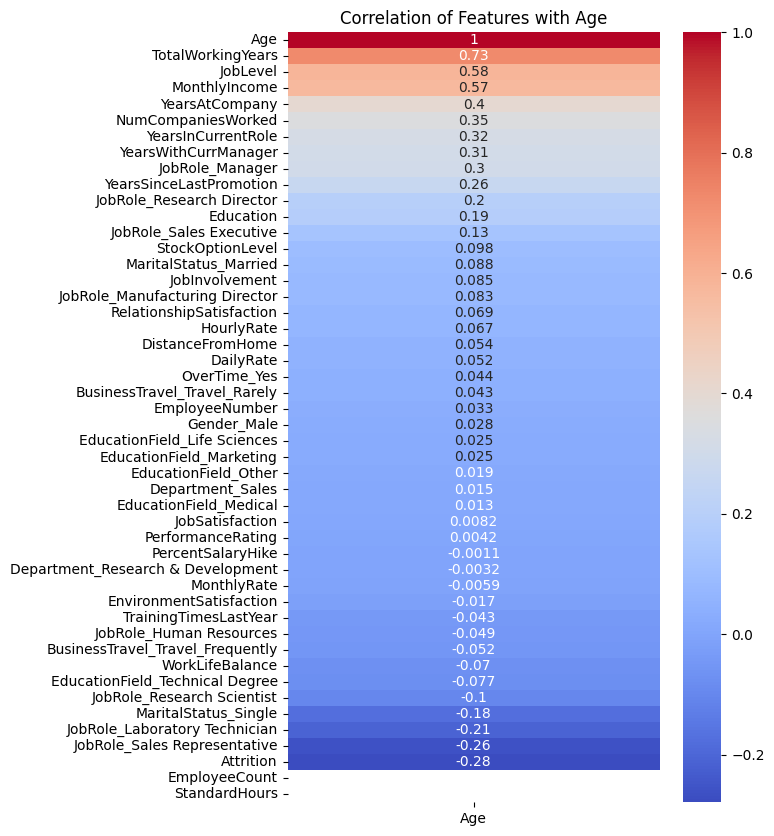

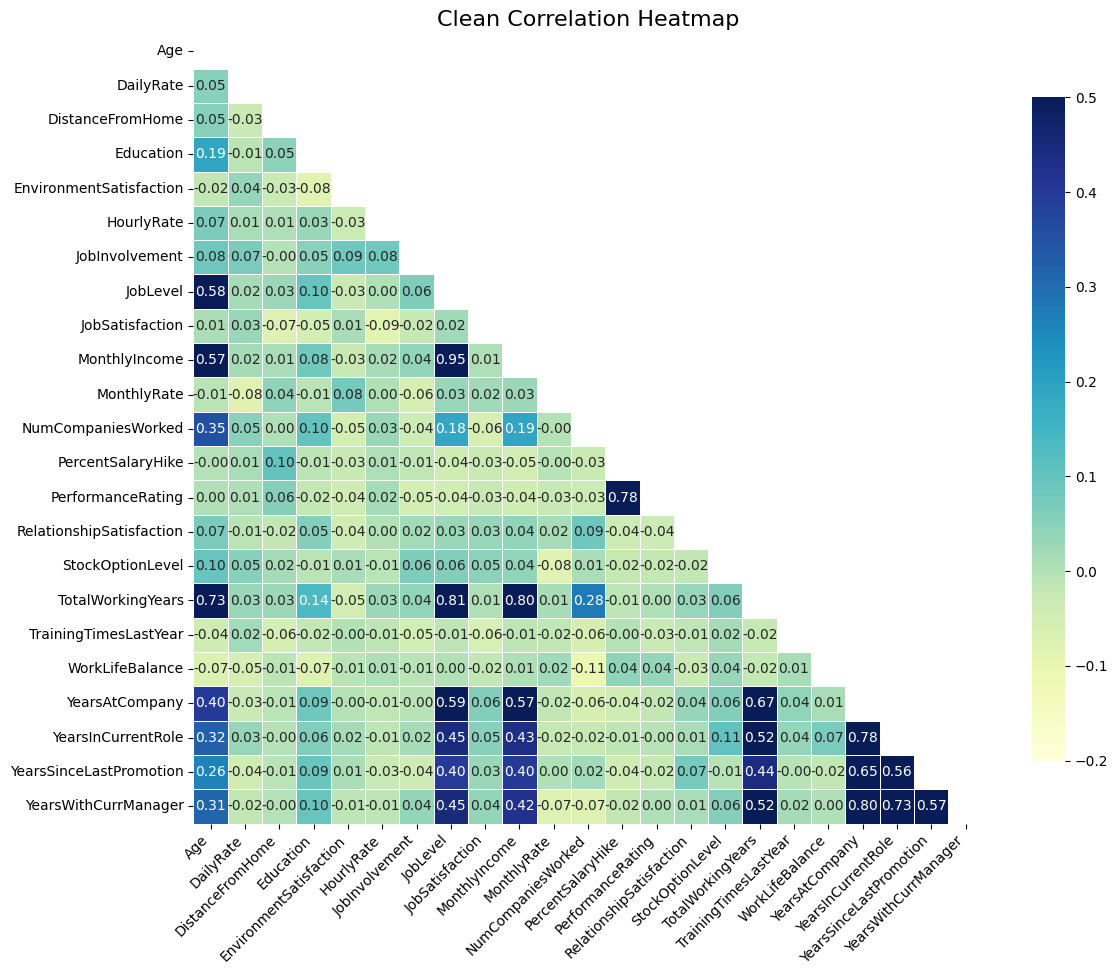


[RSF] Train C-index: 0.9632 | Test C-index: 0.9612
[Meta-XGB] Train AUC: 0.9859 | Accuracy: 0.9400 | Precision: 0.8997 | Recall: 0.9679


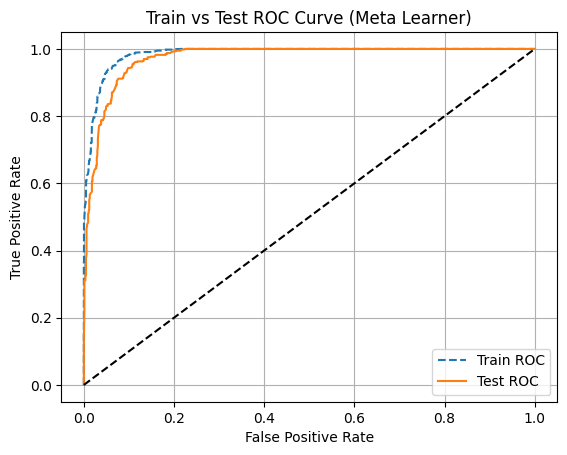

In [ ]:
#codeforsmote
!pip install scikit-survival lifelines -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, roc_curve, auc, confusion_matrix

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from lifelines import CoxPHFitter
from xgboost import XGBClassifier

  # loading synthetic  dataset

df = pd.read_csv("smote7k.csv")


  # Scale YearsAtCompany back to realistic years

df['YearsAtCompany'] = df['YearsAtCompany'] * 10
print(df['YearsAtCompany'].describe())

  # Prepare X, y, T, E

X = df.drop(['Attrition', 'YearsAtCompany'], axis=1)
y = df['Attrition']
T = df['YearsAtCompany'].values
E = y.astype(bool).values

print("X shape:", X.shape, "y shape:", y.shape)

  # Train-test split

X_train, X_test, T_train, T_test, E_train, E_test, y_train, y_test = train_test_split(
      X, T, E, y, test_size=0.2, random_state=42
  )

  # Random Survival Forest

rsf = RandomSurvivalForest(n_estimators=200, min_samples_split=10, min_samples_leaf=15, random_state=42)
rsf.fit(X_train, Surv.from_arrays(E_train, T_train))
print("RSF C-index:", rsf.score(X_test, Surv.from_arrays(E_test, T_test)))

  # CoxPH

cph_df = pd.DataFrame(X)
cph_df['T'] = T
cph_df['E'] = E

  # Drop constant columns
cph_df = cph_df.loc[:, cph_df.std() > 0]

cph = CoxPHFitter()
cph.fit(cph_df, duration_col='T', event_col='E')
print("DeepSurv (CoxPH) C-index:", cph.concordance_index_)

deep_risk_train = -cph.predict_partial_hazard(pd.DataFrame(X_train, columns=X.columns)).values
deep_risk_test = -cph.predict_partial_hazard(pd.DataFrame(X_test, columns=X.columns)).values

  # Meta learner with XGBoost

y_train_class = ((T_train <= 2) & (E_train==1)).astype(int)
y_test_class = ((T_test <= 2) & (E_test==1)).astype(int)

meta_train = np.vstack([deep_risk_train, rsf.predict(X_train)]).T
meta_test = np.vstack([deep_risk_test, rsf.predict(X_test)]).T

xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, use_label_encoder=False, eval_metric='logloss')
xgb.fit(meta_train, y_train_class)
meta_probs = xgb.predict_proba(meta_test)[:,1]
fpr, tpr, _ = roc_curve(y_test_class, meta_probs)
roc_auc = auc(fpr, tpr)
meta_preds = (meta_probs > 0.5).astype(int)

print(f"Meta AUC: {roc_auc:.4f} | Accuracy: {accuracy_score(y_test_class, meta_preds):.4f} | Precision: {precision_score(y_test_class, meta_preds):.4f} | Recall: {recall_score(y_test_class, meta_preds):.4f}")

  # Plots

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange')
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

sns.heatmap(confusion_matrix(y_test_class, meta_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

  # Predicted churn times (using expected value)

pred_surv_funcs = rsf.predict_survival_function(X)

predicted_times = []
for surv_func in pred_surv_funcs:
      expected_time = np.trapz(surv_func.y, surv_func.x)
      predicted_times.append(expected_time)

predicted_times = np.array(predicted_times)

plt.hist(predicted_times, bins=30, color='orange', edgecolor='black')
plt.title("Predicted Churn Times (Years)")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.grid(True)
plt.show()

for i, t in enumerate(predicted_times[:20], 1):
    print(f"Employee {i} likely to churn in approx. {t:.2f} years.")


import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlations with Age
corr = df.corr()

# Extract correlations specifically with Age
age_corr = corr[['Age']].sort_values(by='Age', ascending=False)

# Plot heatmap
plt.figure(figsize=(6,10))
sns.heatmap(age_corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Age")
plt.show()


meta_probs = xgb.predict_proba(meta_test)[:,1]  # Prob of class 1 (early leaver)
fpr, tpr, _ = roc_curve(y_test_class, meta_probs)
roc_auc = auc(fpr, tpr)


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ Select only continuous numeric columns (no one-hot/dummy)
# -------------------------
continuous_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education',
    'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Filter dataset
numerical_df = df[continuous_cols]

# -------------------------
# 2️⃣ Compute correlation matrix
# -------------------------
corr = numerical_df.corr()

# -------------------------
# 3️⃣ Create upper triangle mask
# -------------------------
mask = np.triu(np.ones_like(corr, dtype=bool))

# -------------------------
# 4️⃣ Plot heatmap
# -------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap='YlGnBu',
    vmin=-0.2, vmax=0.5,   # same range as your neat one
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot=True, fmt=".2f"  # show correlation values
)
plt.title("Clean Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ==== Evaluate Train vs Test Performance to Check Overfitting ====

# RSF C-index for Train and Test
rsf_train_cindex = rsf.score(X_train, Surv.from_arrays(E_train, T_train))
rsf_test_cindex = rsf.score(X_test, Surv.from_arrays(E_test, T_test))
print(f"\n[RSF] Train C-index: {rsf_train_cindex:.4f} | Test C-index: {rsf_test_cindex:.4f}")

# Meta Learner AUC & Accuracy on Train Set
meta_train_probs = xgb.predict_proba(meta_train)[:,1]
meta_train_preds = (meta_train_probs > 0.5).astype(int)

train_auc = roc_auc_score(y_train_class, meta_train_probs)
train_acc = accuracy_score(y_train_class, meta_train_preds)
train_prec = precision_score(y_train_class, meta_train_preds)
train_rec = recall_score(y_train_class, meta_train_preds)

print(f"[Meta-XGB] Train AUC: {train_auc:.4f} | Accuracy: {train_acc:.4f} | Precision: {train_prec:.4f} | Recall: {train_rec:.4f}")

# ===== Optional: Compare ROC curves visually =====
fpr_train, tpr_train, _ = roc_curve(y_train_class, meta_train_probs)
fpr_test, tpr_test, _ = roc_curve(y_test_class, meta_probs)

plt.figure()
plt.plot(fpr_train, tpr_train, label='Train ROC', linestyle='--')
plt.plot(fpr_test, tpr_test, label='Test ROC')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC Curve (Meta Learner)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ===== Churn Time for ALL Employees =====

# Create DataFrame with employee index and predicted churn time
churn_df = pd.DataFrame({
    "Employee_Index": range(1, len(predicted_times) + 1),
    "Predicted_Churn_Time_Years": predicted_times
})

# Print the full table in console
print(churn_df)

# Optional: Save to CSV
churn_df.to_csv("predicted_churn_times.csv", index=False)
print("\nPredicted churn times saved to 'predicted_churn_times.csv'")

      Employee_Index  Predicted_Churn_Time_Years
0                  1                    4.414259
1                  2                    1.792737
2                  3                    5.405643
3                  4                    0.090131
4                  5                    5.720572
...              ...                         ...
6995            6996                    0.759290
6996            6997                    0.391736
6997            6998                    4.947188
6998            6999                    1.357023
6999            7000                    0.439301

[7000 rows x 2 columns]

Predicted churn times saved to 'predicted_churn_times.csv'


In [ ]:
# # First, ensure necessary libraries are installed
!pip install scikit-survival lifelines scikit-learn pandas
numpy xgboost matplotlib seaborn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score,
confusion_matrix
from sklearn.cross_decomposition import CCA # <-- Added import
for CCA
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from lifelines import CoxPHFitter
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore', category=UserWarning,
module='xgboost')
warnings.filterwarnings('ignore', category=FutureWarning)

try:
df = pd.read_csv("smote7k.csv")
except FileNotFoundError:
print("Error: 'smote7k.csv' not found. Please ensure the
dataset is in the correct directory.")
exit()

df.columns = df.columns.str.replace('[^A-Za-z0_9_]+', '_',
regex=True)


print("\n--- Running Canonical Correlation Analysis (CCA) to
create new features ---
")

x_cols = [
'Age', 'DailyRate',
'DistanceFromHome', 'Education',
'EnvironmentSatisfaction',
'HourlyRate', 'JobInvolvement', 'JobLevel',
'JobSatisfaction',
'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
'PercentSalaryHike',
'PerformanceRating', 'RelationshipSatisfaction',
'StockOptionLevel',
'TrainingTimesLastYear',
'WorkLifeBalance','JobRole_Sales_Representative',
'MaritalStatus_Married', 'MaritalStatus_Single',
'OverTime_Yes'
]
y_cols = [
'TotalWorkingYears', 'YearsAtCompany',
'YearsInCurrentRole',
'YearsSinceLastPromotion',
'YearsWithCurrManager','BusinessTravel_Travel_Frequently',
'BusinessTravel_Travel_Rarely',
'Department_Research___Development',
'Department_Sales', 'EducationField_Life_Sciences',
'EducationField_Marketing',
'EducationField_Medical', 'EducationField_Other',
'EducationField_Technical_Degree',
'Gender_Male', 'JobRole_Human_Resources',
'JobRole_Laboratory_Technician',
'JobRole_Manager', 'JobRole_Manufacturing_Director',
'JobRole_Research_Director',
'JobRole_Research_Scientist', 'JobRole_Sales_Executive'
]

cleaning names
x_cols = [col for col in x_cols if col in df.columns]
y_cols = [col for col in y_cols if col in df.columns]
X_cca_original = df[x_cols]
Y_cca_original = df[y_cols]


n_cca_components = min(X_cca_original.shape[1],
Y_cca_original.shape[1])
cca = CCA(n_components=n_cca_components)
X_c, Y_c = cca.fit_transform(X_cca_original, Y_cca_original)

cca_features_df = pd.DataFrame(X_c,
columns=[f'CCA_Variate_{i+1}' for i in
range(n_cca_components)])
print(f"CCA generated {cca_features_df.shape[1]} new
features.")


T = df['YearsAtCompany'].values
E = df['Attrition'].astype(bool).values
y_class_target = ((T <= 2) & (E == True)).astype(int) # Target
for meta-learner
print(f"\nDataset shape: {df.shape}")
print(f"Feature matrix X (from CCA) shape: {X.shape}") # This
will now show the CCA features shape
print(f"Target class distribution (Churn <= 2
years):\n{pd.Series(y_class_target).value_counts(normalize=True
)}\n")

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
random_state=42)
test_auc_scores = []
test_accuracy_scores = []
correctly_classified_counts = []
incorrectly_classified_counts = []
print(f"
--- Starting {n_splits}-Fold Cross-Validation with CCA
Features ---
")

for fold, (train_index, test_index) in enumerate(skf.split(X,
y_class_target)):
print(f"Processing Fold {fold+1}/{n_splits}...")
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
T_train, T_test = T[train_index], T[test_index]
E_train, E_test = E[train_index], E[test_index]
y_train_class, y_test_class = y_class_target[train_index],
y_class_target[test_index]

rsf = RandomSurvivalForest(n_estimators=200,
min_samples_split=10, min_samples_leaf=15, random_state=42,
n_jobs=-1)
rsf.fit(X_train, Surv.from_arrays(E_train, T_train))
rsf_risk_train = rsf.predict(X_train)
rsf_risk_test = rsf.predict(X_test)

cph_train_df = X_train.copy()
cph_train_df['T'] = T_train
cph_train_df['E'] = E_train

cph = CoxPHFitter()
features_for_cph = cph_train_df.drop(['T', 'E'], axis=1,
errors='ignore')
cph.fit(cph_train_df, duration_col='T', event_col='E',
formula=" + ".join(features_for_cph.columns))
train_cols = features_for_cph.columns
deep_risk_train = -
cph.predict_partial_hazard(X_train[train_cols]).values.flatten(
)
deep_risk_test = -
cph.predict_partial_hazard(X_test[train_cols]).values.flatten()

meta_train = np.vstack([deep_risk_train, rsf_risk_train]).T
meta_test = np.vstack([deep_risk_test, rsf_risk_test]).T
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05,
max_depth=3, use_label_encoder=False, eval_metric='logloss',
random_state=42)
xgb.fit(meta_train, y_train_class)


meta_probs = xgb.predict_proba(meta_test)[:, 1]
meta_preds = (meta_probs > 0.5).astype(int)

test_auc_scores.append(roc_auc_score(y_test_class,
meta_probs))
test_accuracy_scores.append(accuracy_score(y_test_class,
meta_preds))
cm = confusion_matrix(y_test_class, meta_preds)
correctly_classified_counts.append(np.trace(cm))
incorrectly_classified_counts.append(len(y_test_class) -
np.trace(cm))

print("\n\n--- FINAL MODEL EVALUATION SUMMARY (with CCA
Features) ---
")
avg_accuracy = np.mean(test_accuracy_scores) * 100
avg_correct = np.mean(correctly_classified_counts)
avg_incorrect = np.mean(incorrectly_classified_counts)
total_samples_per_fold = len(test_index)
summary_data = {
'Metric': [
'Correctly classified',
'Incorrectly classified',
'Accuracy using cross-validation (%)'
],
'Value': [
f'{avg_correct:.0f} (avg per fold)',
f'{avg_incorrect:.0f} (avg per fold)',
f'{avg_accuracy:.1f}%'
]
}
summary_df = pd.DataFrame(summary_data)
print(f"Model: Meta-Learner (CCA + RSF + CoxPH + XGBoost)")
print(f"Number of Data Points per Fold (Test Set):
{total_samples_per_fold}")
print("
-
" * 50)
print(summary_df.to_string(index=False, header=False))
print("
-
" * 50)
----

automatically)
----
print("\n--- Predicting Churn Time for All Employees (using CCA
features) ---
")

final_rsf = RandomSurvivalForest(n_estimators=200,
min_samples_split=10, min_samples_leaf=15, random_state=42,
n_jobs=-1)
final_rsf.fit(X, Surv.from_arrays(E, T))
pred_surv_funcs = final_rsf.predict_survival_function(X)

predicted_times = [np.trapz(surv_func.y, surv_func.x) for
surv_func in pred_surv_funcs]
predicted_times = np.array(predicted_times)


      predictions_df = pd.DataFrame({'EmployeeID': X.index,
'PredictedChurnTime_Years': predicted_times})
print("\nPredicted churn times for the first 20 employees:")
for index, row in predictions_df.head(20).iterrows():
print(f"Employee {int(row['EmployeeID'])} is likely to
churn in approx. {row['PredictedChurnTime_Years']:.2f} years.")


plt.figure(figsize=(10, 6))
plt.hist(predicted_times, bins=30, color='skyblue',
edgecolor='black')
plt.title("Distribution of Predicted Employee Churn Times
(using CCA model)")
plt.xlabel("Predicted Years at Company Until Churn")
plt.ylabel("Number of Employees")
plt.grid(axis='y', alpha=0.75)